In [1]:
#Unet
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import re

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack
from centerline.src.make_skeleton import make_skeleton

2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
img038208.tif


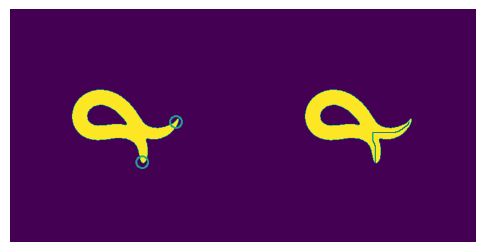

img038227.tif


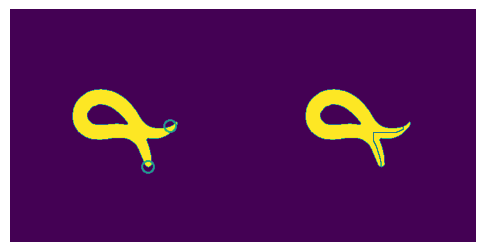

img038247.tif


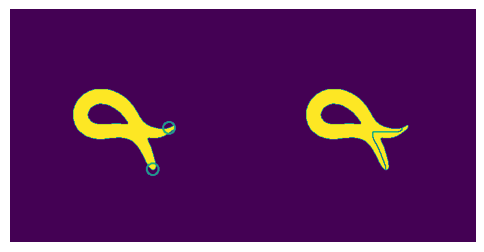

img038272.tif


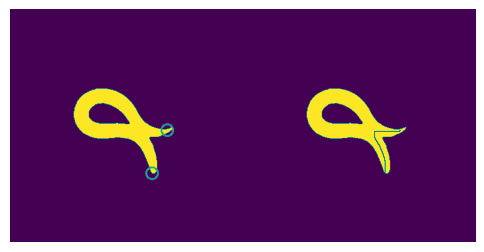

img038274.tif


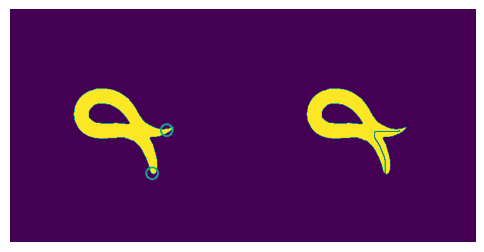

img038414.tif


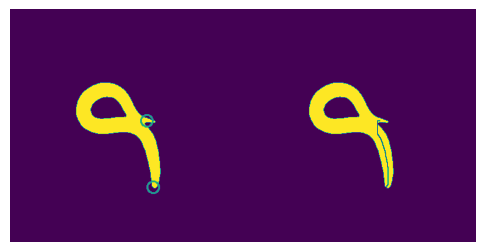

img038434.tif


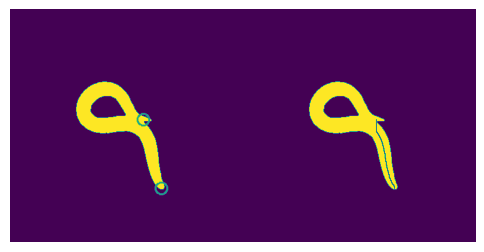

img188775.tif


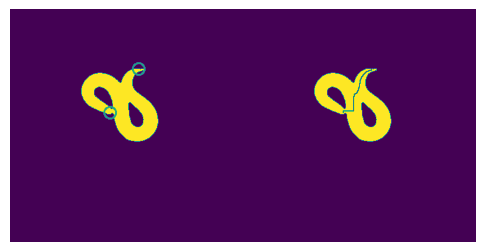

img189209.tif


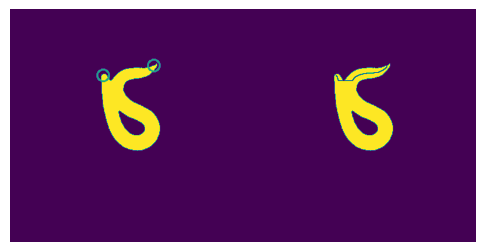

img189271.tif


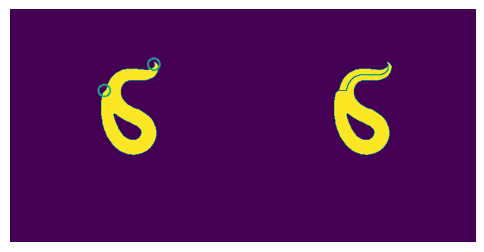

Failed centerlines:  27 
Very short centerlines: 10 
Good centerlines:  0 
Total centerlines:  37
2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
0
img000000.tif


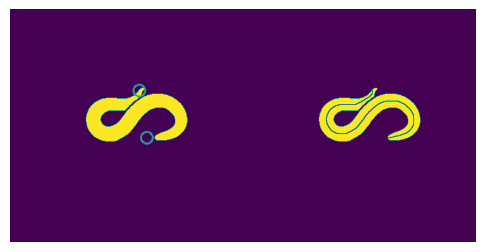

78
img000078.tif


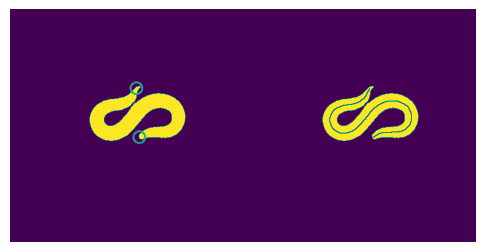

img010324.tif


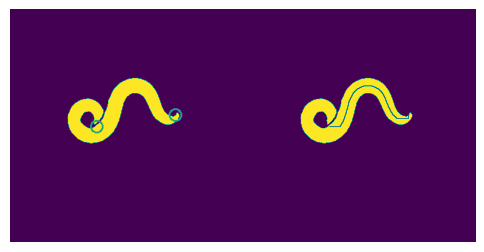

img010437.tif


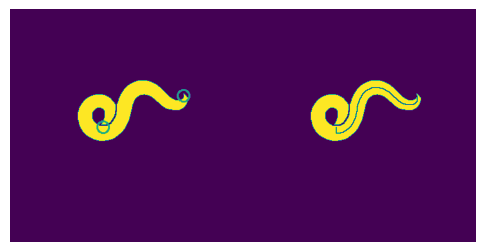

10804
img010804.tif


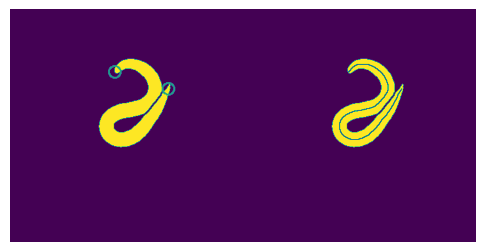

70070
img070070.tif


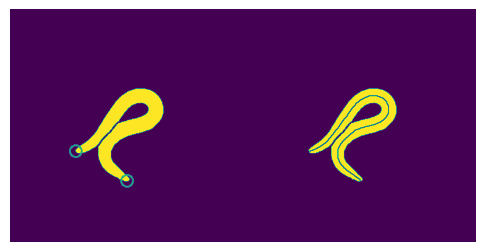

70160
img070160.tif


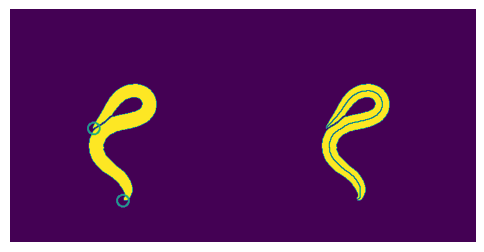

70238
img070238.tif


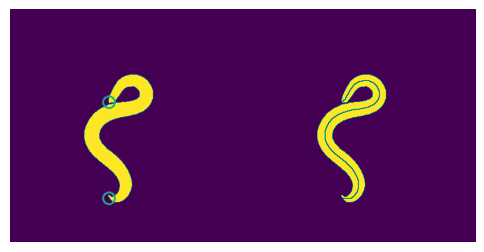

70422
img070422.tif


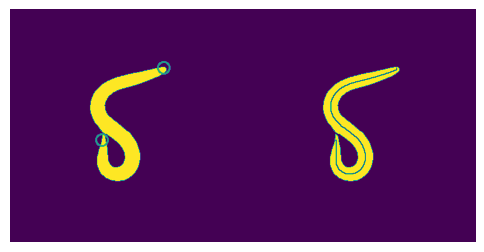

70593
img070593.tif


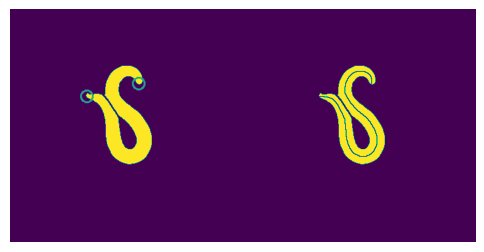

71126
img071126.tif


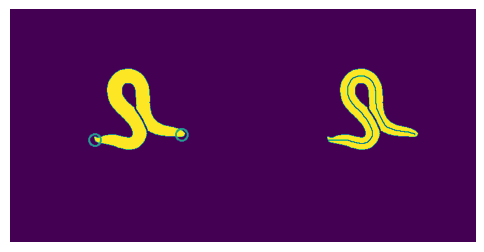

img118293.tif


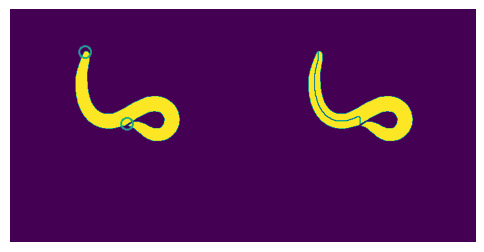

img118307.tif


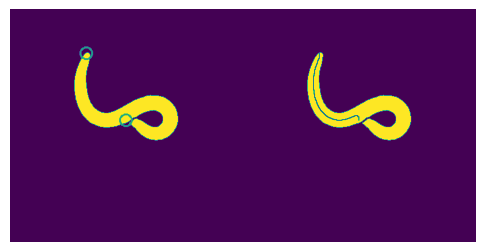

img118374.tif


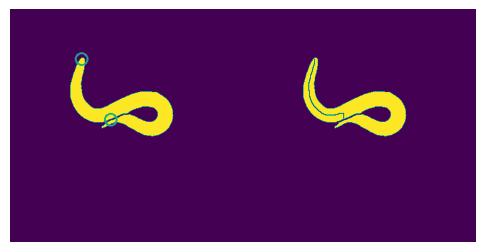

118411
img118411.tif


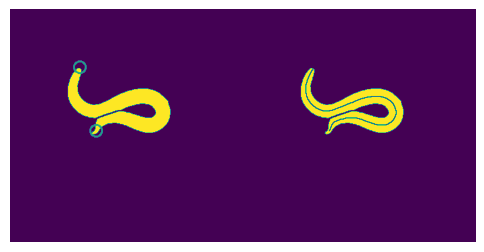

118457
img118457.tif


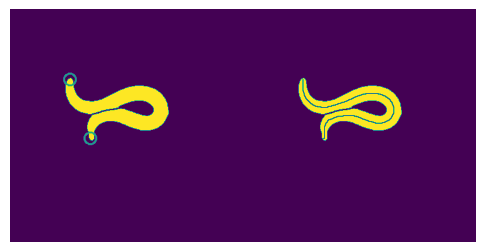

118480
img118480.tif


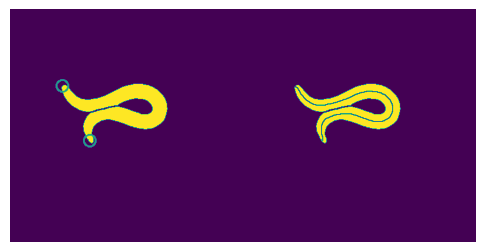

118509
img118509.tif


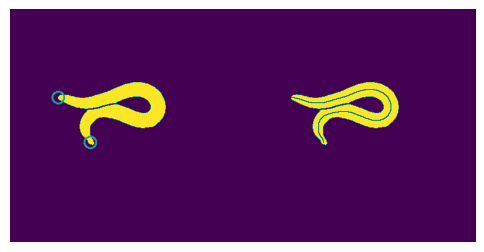

118544
img118544.tif


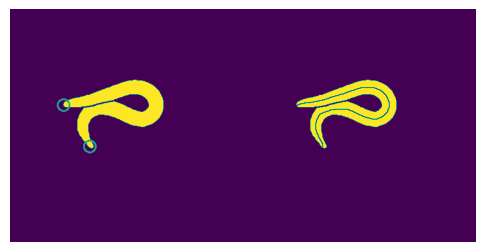

118660
img118660.tif


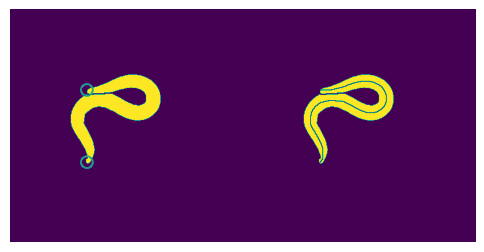

img118712.tif


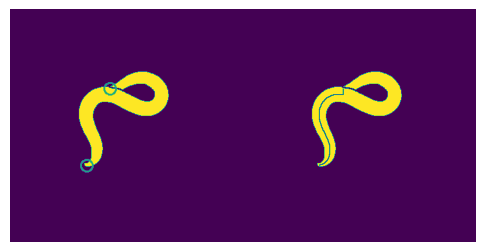

118777
img118777.tif


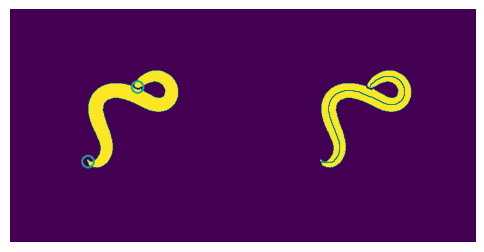

Failed centerlines:  0 
Very short centerlines: 6 
Good centerlines:  16 
Total centerlines:  22
2020-07-01_18-36-25_control_worm6-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
img000140.tif


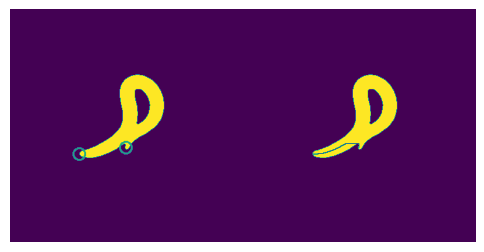

img000174.tif


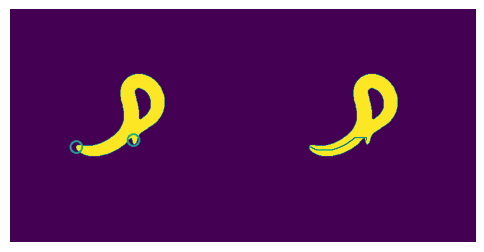

img000207.tif


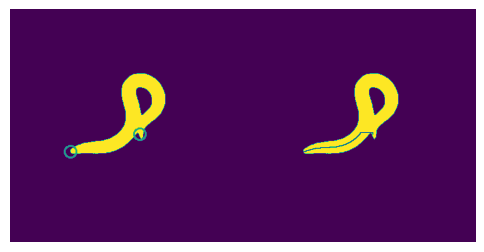

img000245.tif


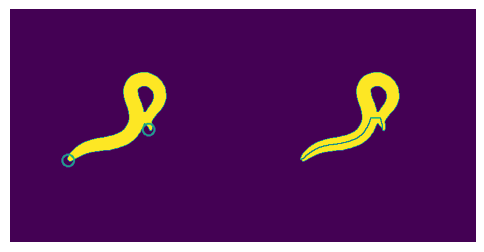

img000256.tif


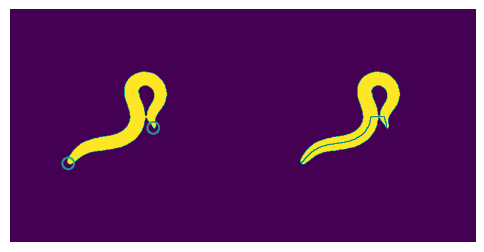

img002739.tif


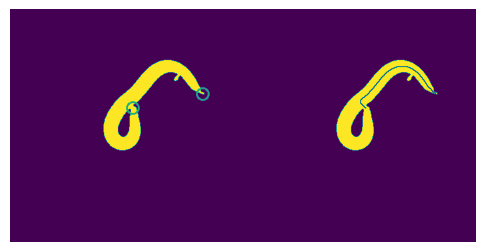

img002754.tif


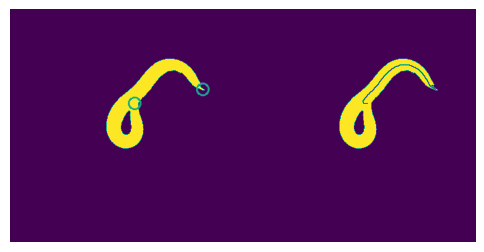

img002775.tif


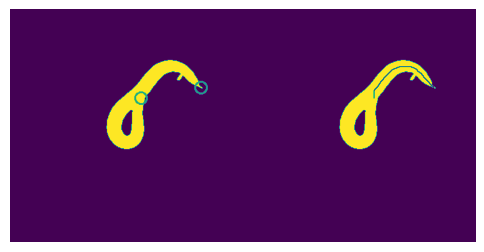

img002798.tif


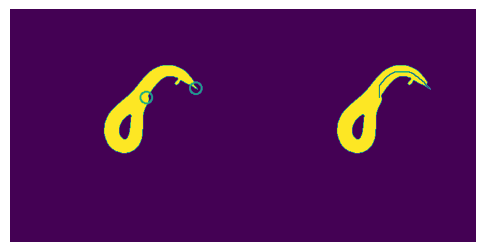

img002809.tif


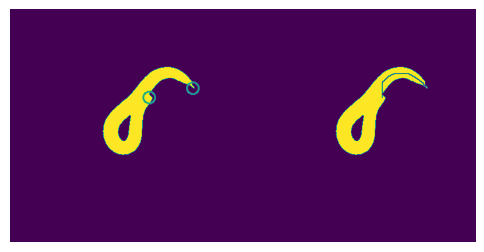

img002820.tif


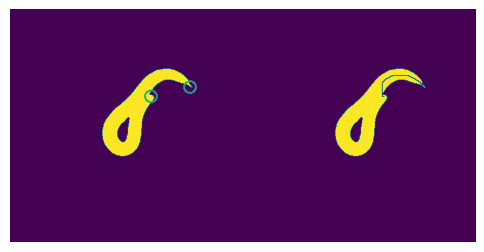

img003017.tif


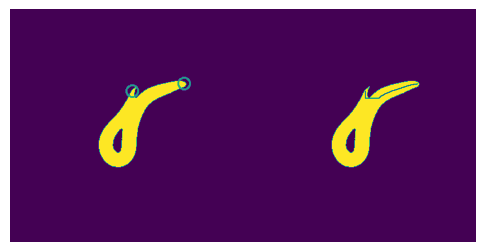

img003072.tif


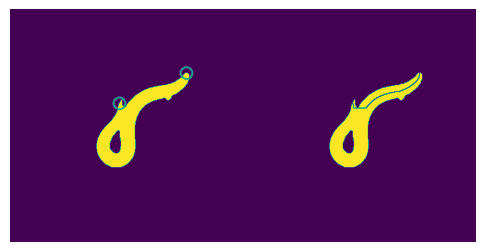

img003110.tif


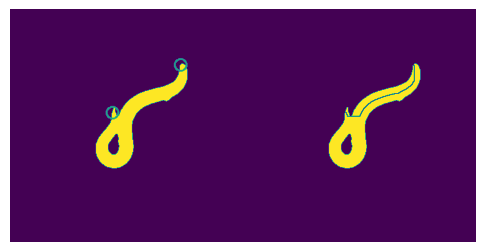

img003128.tif


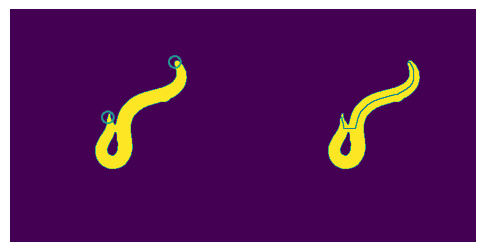

img005243.tif


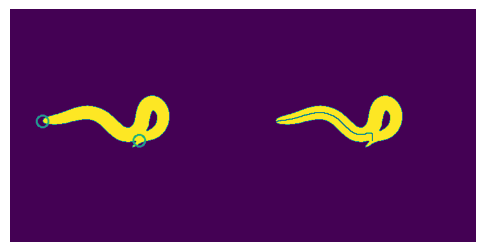

img005259.tif


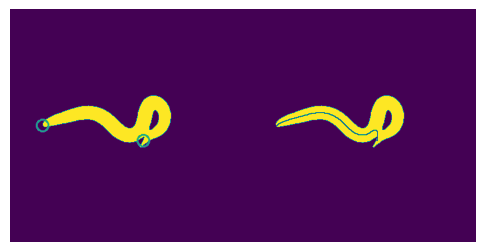

img006961.tif


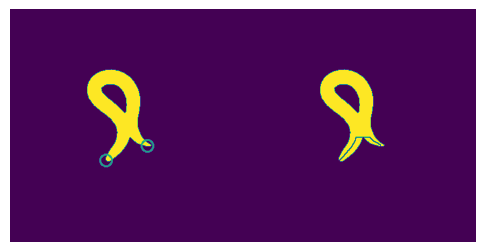

img006984.tif


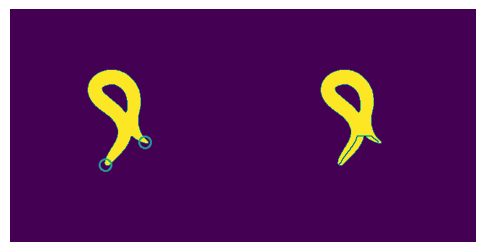

img007006.tif


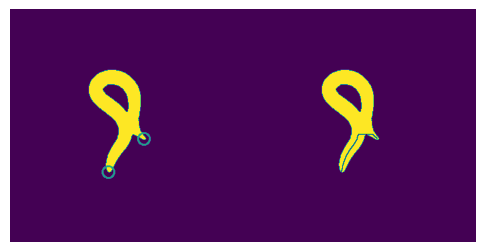

img007033.tif


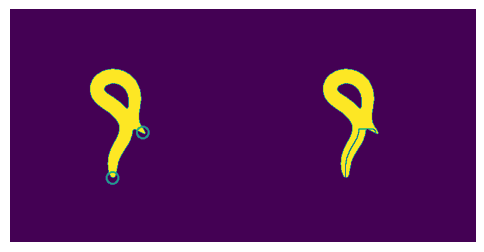

img007070.tif


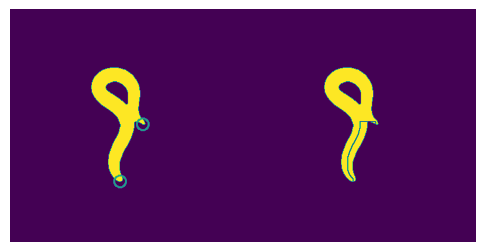

img007103.tif


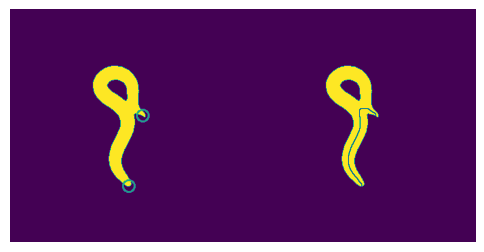

img007125.tif


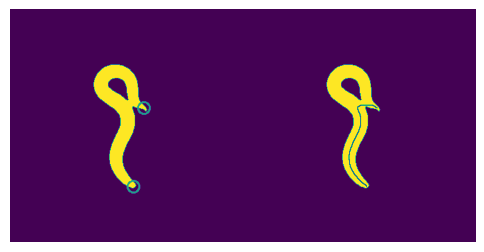

img021705.tif


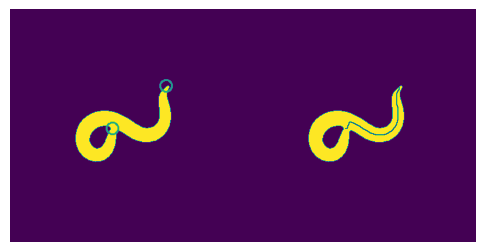

img021745.tif


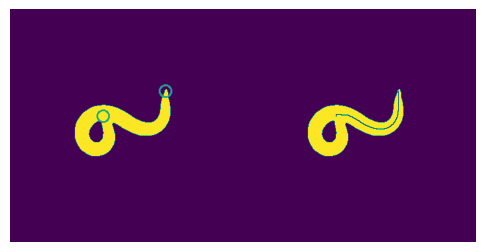

img021775.tif


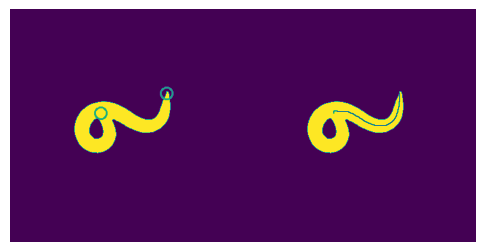

img021805.tif


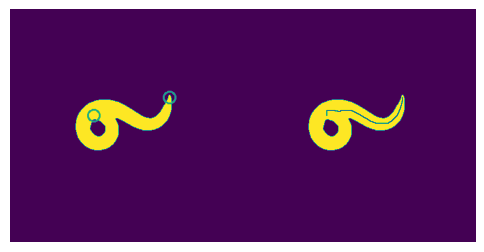

img021834.tif


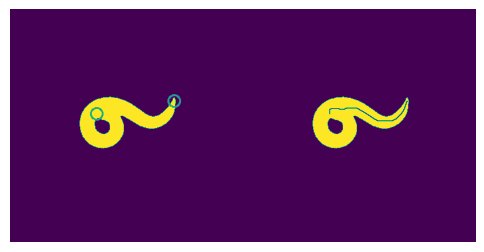

img021901.tif


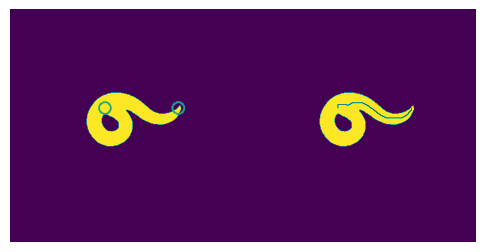

img021944.tif


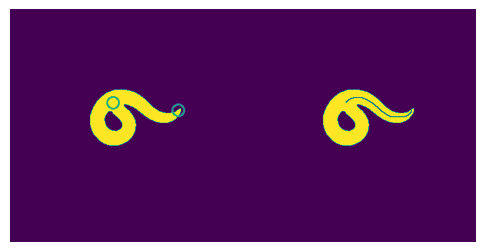

img021966.tif


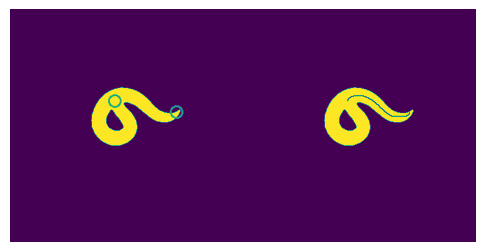

img021974.tif


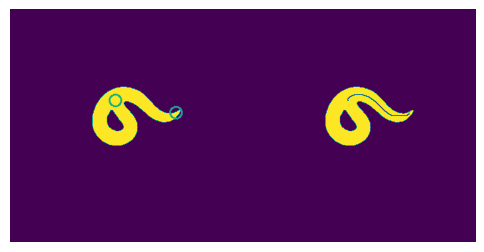

img022250.tif


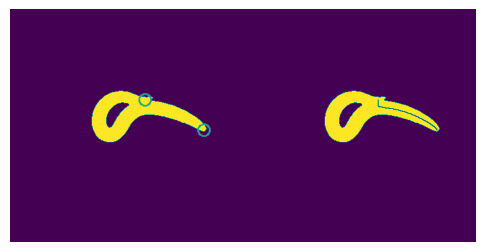

img022286.tif


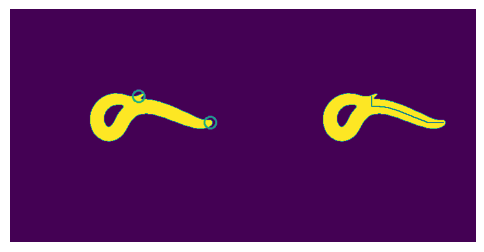

img022314.tif


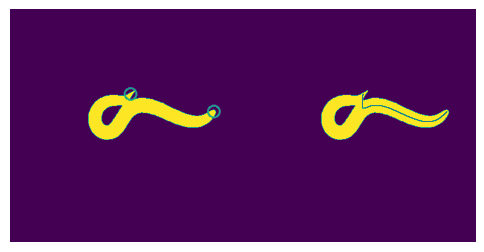

img024362.tif


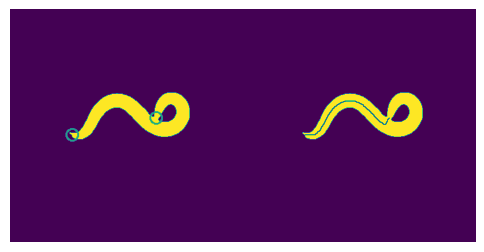

img024414.tif


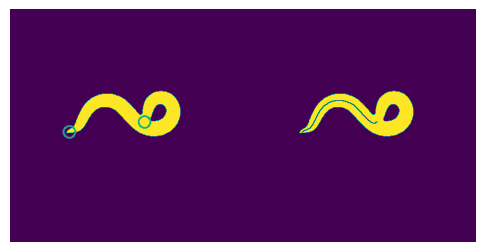

img024444.tif


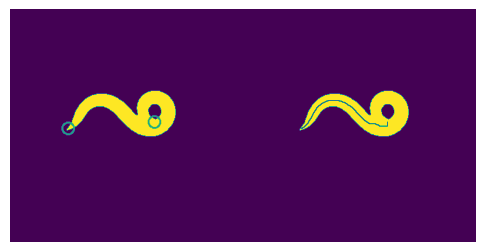

img024489.tif


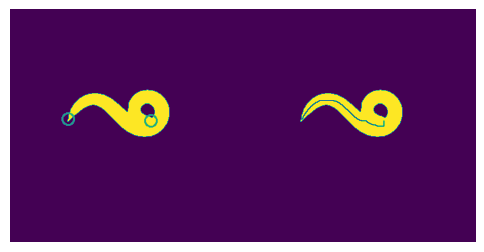

img024563.tif


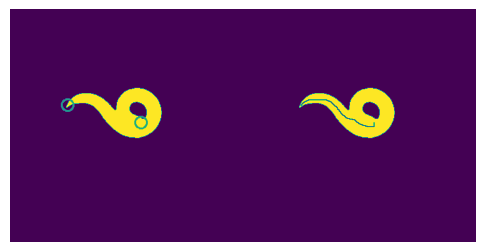

img024623.tif


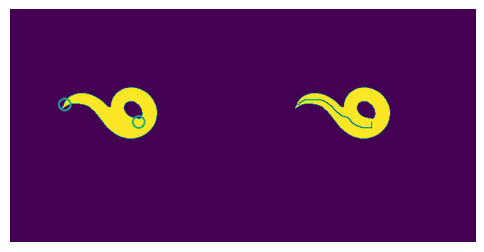

img024683.tif


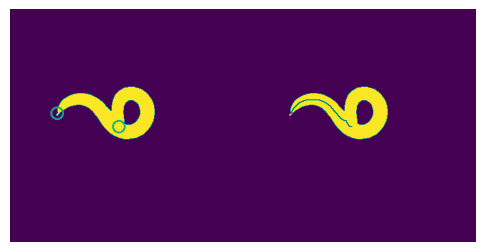

img024743.tif


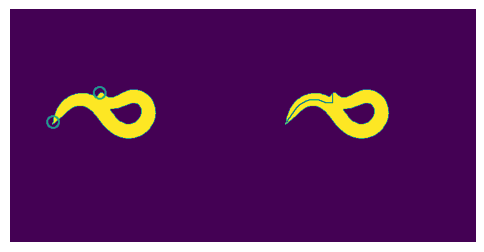

img024803.tif


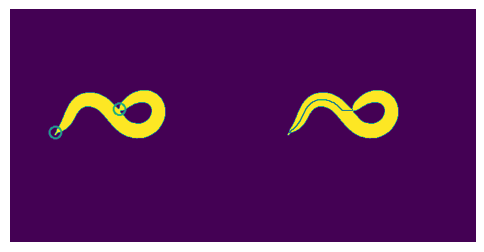

img027739.tif


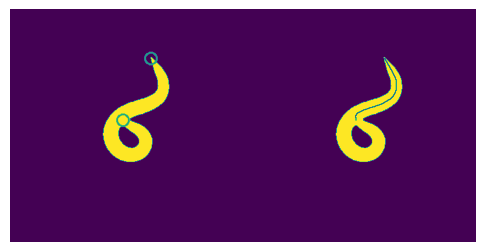

img027799.tif


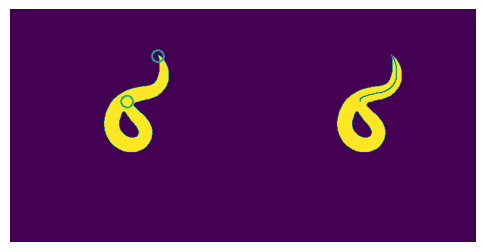

img027979.tif


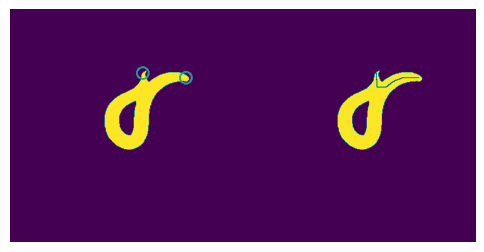

img028039.tif


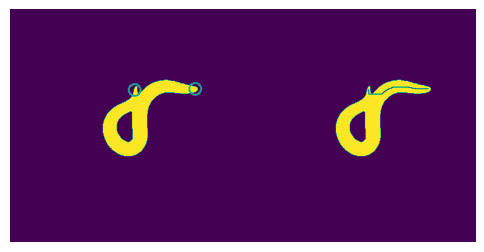

img028099.tif


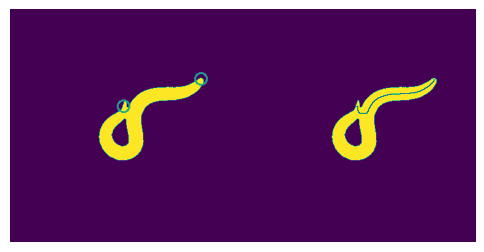

img034797.tif


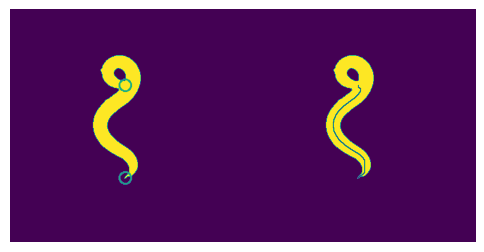

img034917.tif


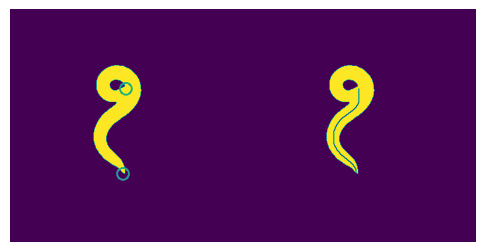

img034977.tif


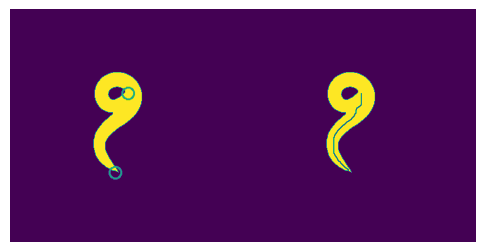

img035037.tif


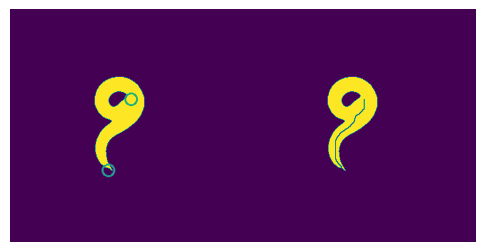

img035097.tif


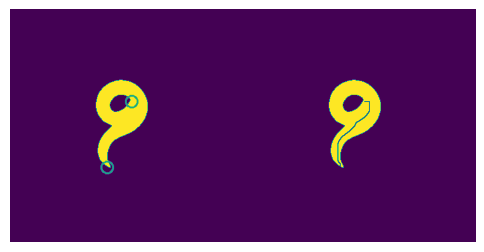

img035157.tif


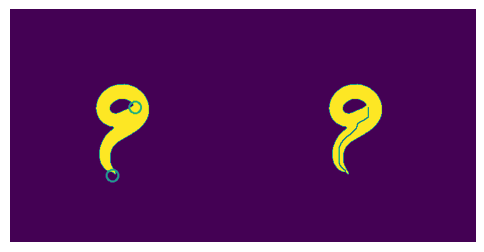

img035217.tif


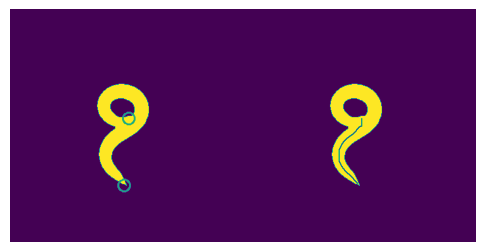

img035277.tif


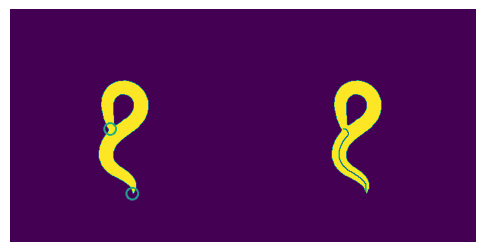

img039862.tif


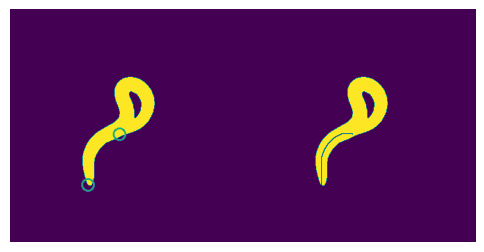

img039922.tif


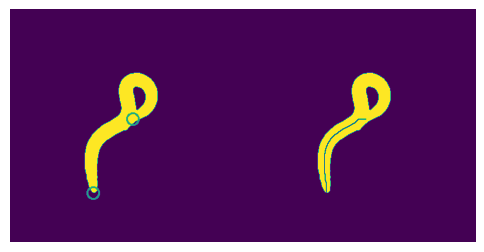

img048080.tif


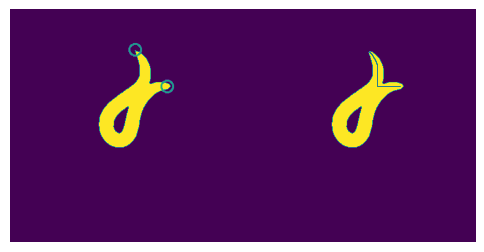

img048140.tif


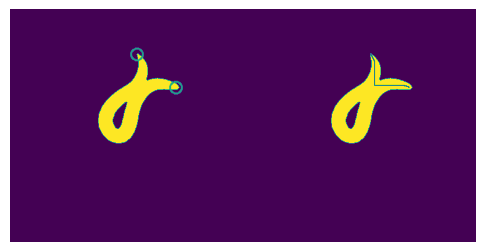

img048200.tif


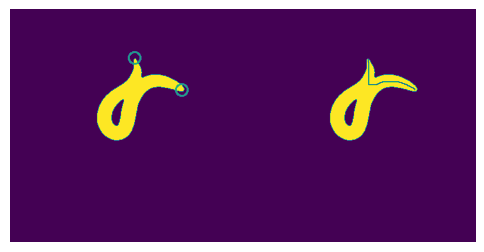

img048260.tif


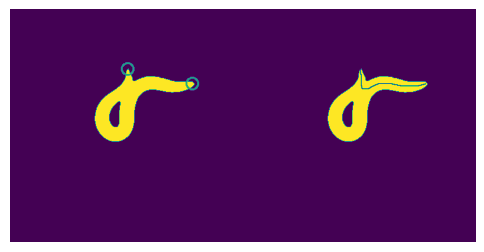

img048320.tif


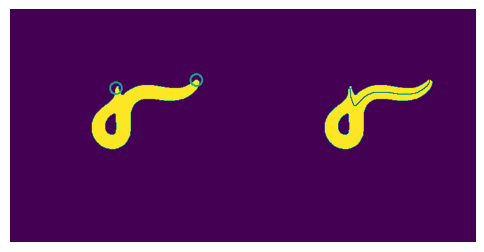

img059647.tif


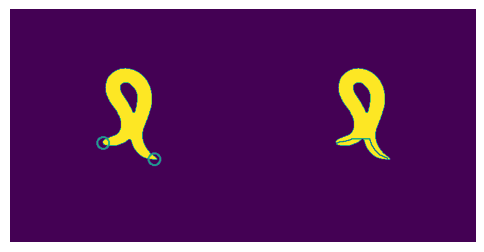

img059707.tif


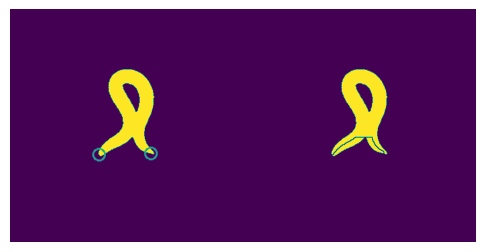

img059767.tif


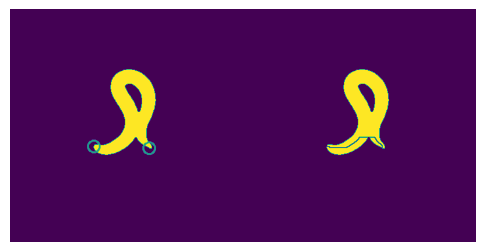

img059827.tif


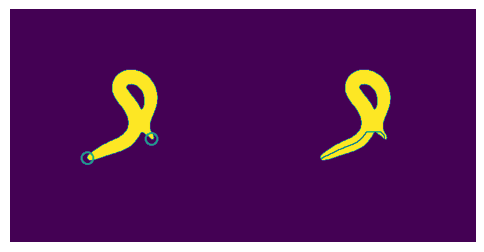

img059887.tif


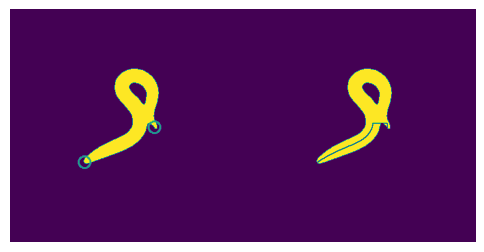

img062763.tif


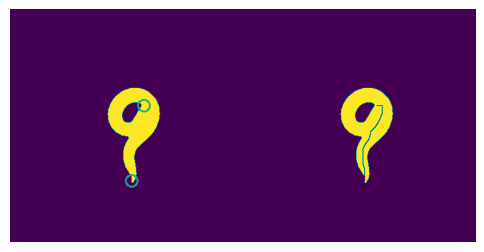

img062823.tif


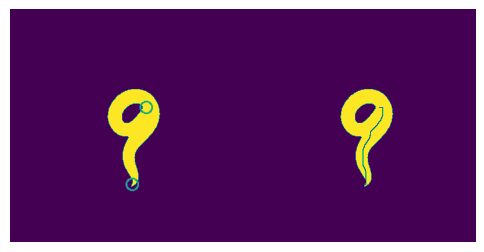

img062883.tif


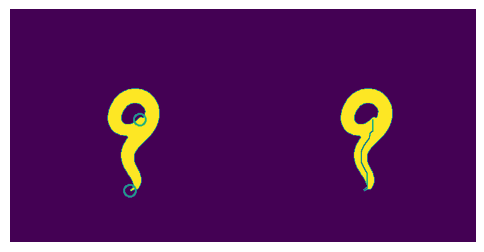

img062943.tif


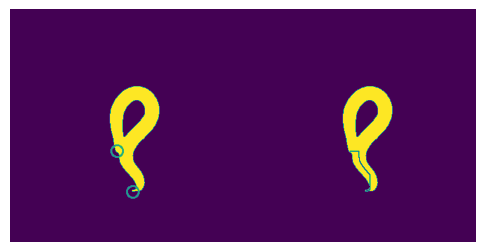

img063003.tif


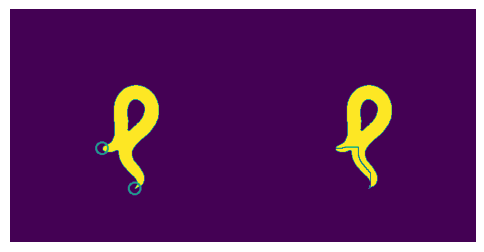

img063063.tif


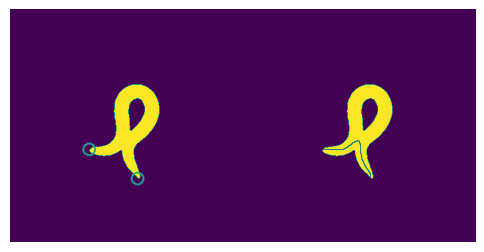

img063123.tif


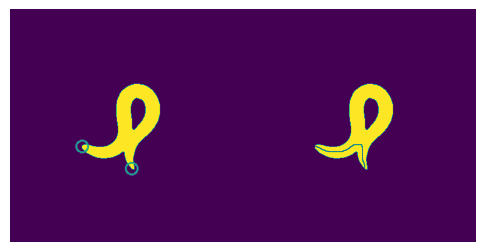

img063183.tif


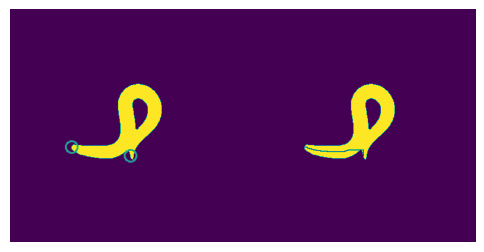

img063243.tif


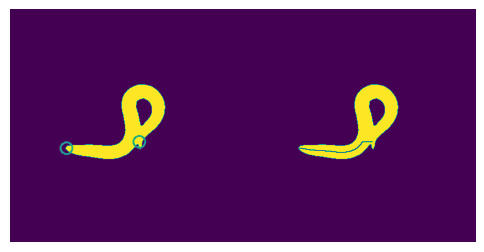

img108725.tif


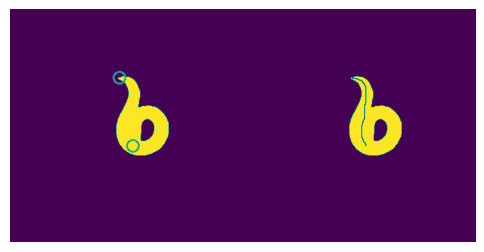

img108845.tif


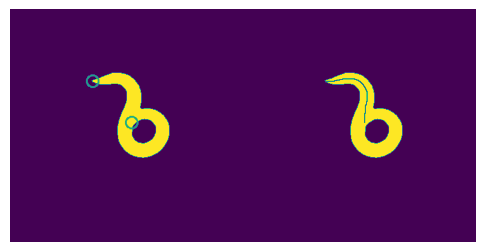

img108905.tif


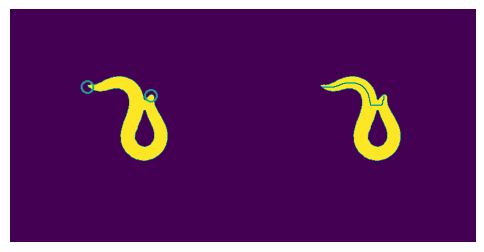

img109085.tif


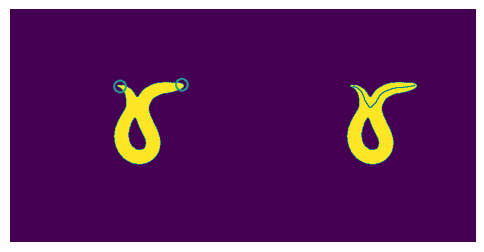

img109145.tif


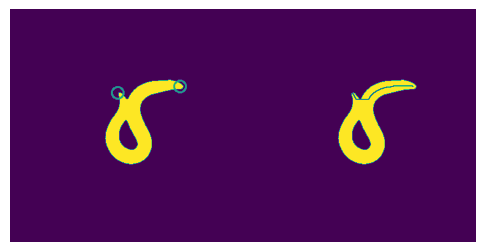

img109205.tif


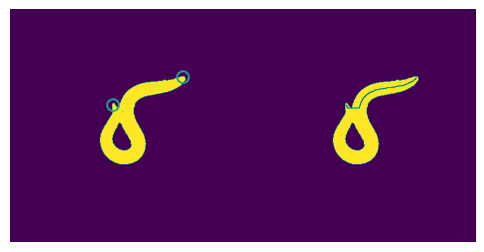

img117011.tif


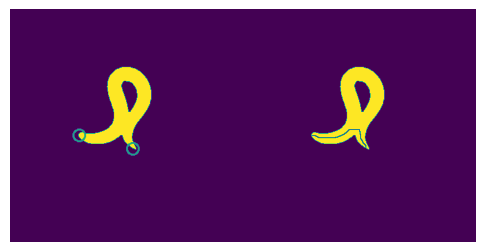

img117071.tif


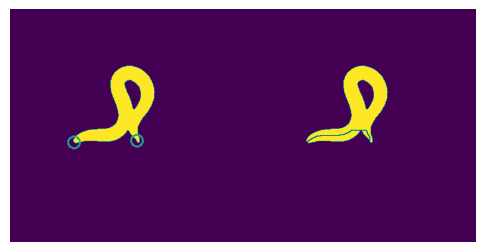

img117131.tif


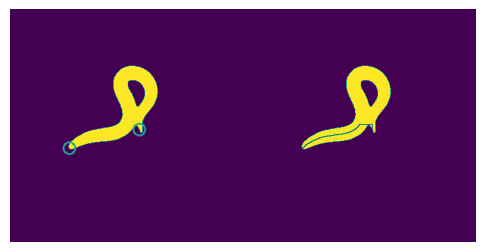

Failed centerlines:  28 
Very short centerlines: 88 
Good centerlines:  0 
Total centerlines:  116
ExtractedData_Ulises_2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.csv
[]


IndexError: list index out of range

In [5]:
#I should rewrite-rearrange this more modular!

import os
import glob

#define number of splines
num_splines=100

#define expected skeleton minimum length
skel_min_length=300

#Compile regular expressions into pattern objects 
regex = re.compile(r'\d+')

main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/'

for folder in natsorted(os.listdir(main_path)):
    if '.DS' in folder: continue
    print(folder)
    h5_path=glob.glob(os.path.join(main_path,folder)+'/*.h5')
    #print(os.path.join(main_path,folder))
    print(h5_path)
    print(h5_path[0])
    
    df=pd.read_hdf(h5_path[0])
    
    img_path=os.path.join(main_path,folder,'binary/')
    #print(img_path)
    
    output_path=os.path.join(main_path,folder,'centerlines2/')
    os.makedirs(output_path,exist_ok=True)
    #print(output_path)
    img_list=natsorted(os.listdir(img_path))

    scorer=df.columns.get_level_values(0)[0]
    head_x=df[scorer]['Head']['x'].values
    head_y=df[scorer]['Head']['y'].values
    tail_x=df[scorer]['Tail']['x'].values
    tail_y=df[scorer]['Tail']['y'].values
    
    #create writer object
    csvfileX=open(output_path+'spline_X_coords.csv','w', newline='')
    csvfileX_writer=csv.writer(csvfileX)
    csvfileY=open(output_path+'spline_Y_coords.csv','w', newline='')
    csvfileY_writer=csv.writer(csvfileY)

    csvfilename=open(output_path+'filename.csv','w', newline='')
    csvfilename_writer=csv.writer(csvfilename)
    #set counters for failed centerlines
    c1=0
    c2=0



    for filename in img_list:
        if 'img' in filename:

            #print(filename)
            
            #this int() might be not a good idea, check!
            i=int(regex.search(filename).group(0))
            #print(i)
            start_point=(int(head_y[i]), int(head_x[i]))
            end_point = (int(tail_y[i]), int(tail_x[i]))
            #print(start_point)
            #print(end_point)

            img=tiff.imread(os.path.join(img_path,filename))

            annotated_img=img.copy()
            cv2.circle(annotated_img,(int(head_x[i]), int(head_y[i])),10, (150,150,150), 2)
            cv2.circle(annotated_img,(int(tail_x[i]), int(tail_y[i])),10, (150,150,150), 2)

    #         plt.figure(figsize=(10,10), dpi=150)
    #         plt.subplot(1,2,1)
    #         plt.imshow(annotated_img)

            u, skel_coords, spline_coords, K=make_skeleton(start_point, end_point,num_splines, img)
            #print(skel_coords[0].shape)

            #try to unpack the skel_coords as an array of int (will fail if skel_coords contains NaN)
            try: coords=np.asarray(list(zip(*skel_coords)), dtype=int)# the dtype=int makes sures no NaN can be passed, which will cause trouble when indexing
            except:
                c1=c1+1
                #print('head and tail were too close, no centerline could be created', c1)

            else:
                #counter for short skel coords
                if len(skel_coords[0])<=skel_min_length:
                    c2=c2+1
                    #print('short centerline', c2)

                #draw zeros on the skel_img where the are coordinates
                skel_img=img.copy()
                for idx,coords in enumerate(coords):
                    skel_img[coords[0],coords[1]]=0

                #save coordinates of the good centerlines
                if len(skel_coords[0])>skel_min_length:
                    print(i)
                    x,y=np.asarray(spline_coords)
                    csvfileX_writer.writerow(x)
                    csvfileY_writer.writerow(y)
                    #would [filename] alone work? filename without[] writes every letter in a different cell
                    csvfilename_writer.writerow([os.path.join('labeled-data',folder,filename)])#(['filename:',filename])
                #plotting
                ##if i!=0: continue
                print(filename)
                #plt.figure(figsize=(10,10), dpi=100)
                
                
                fig, axes = plt.subplots(nrows=1, ncols=2, dpi=100)
                axes[0].imshow(annotated_img)
                axes[1].imshow(skel_img)
                #axes[0].set_aspect('equal')
                for ax in axes:
                    ax.set_xlim(100, 500)
                    ax.set_ylim(100, 500)
                    ax.axis('off')
                #axes[1].axis('off')
                #axes[1].set_aspect('equal')
                fig.subplots_adjust(wspace=0, hspace=0)
                plt.show()
                #break
                #check if the skel_coords are too short
    csvfileX.close()
    csvfileY.close()
    csvfilename.close()
    print('Failed centerlines: ', c1,'\nVery short centerlines:', c2, '\nGood centerlines: ', len(img_list)-c1-c2,'\nTotal centerlines: ', len(img_list))



In [1]:
# trying to get centerline output coordinates from dlc to fit into spline


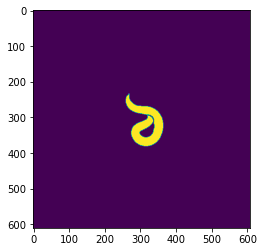

In [4]:
img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/binary_segmented/img000000.tif')
plt.imshow(img)

In [5]:
costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
costs=costs.max()-costs


#to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
costs=np.where(costs>254.9, 255*100, costs)
#actual skeleton based on shortest_path of skimage
#actual skeleton based on route through array from skimage

start_point, end_point =(326,300),(268,237)
path, cost = skimage.graph.route_through_array(costs, start=start_point, end=end_point, fully_connected=False)
pts=np.asarray(path, dtype=np.int)

In [12]:
pts[0]

array([326, 300])

In [8]:
tck, u = splprep(pts.T, u=None, s=pts.shape[0], per=0, k=4) 


In [11]:
tck

[array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.25074627, 0.3761194 , 0.50149254, 0.75223881, 0.87761194,
        1.        , 1.        , 1.        , 1.        , 1.        ]),
 [array([324.99086156, 331.48582846, 369.35256206, 376.85991278,
         333.88253717, 273.81912831, 283.77416537, 267.25881936,
         265.20200565, 269.7295514 ]),
  array([301.20716097, 279.61357968, 283.56552664, 332.38067858,
         357.6681598 , 352.27779871, 295.71642144, 268.52015845,
         249.58979943, 235.64942389])],
 4]

In [7]:
print(type(path))


print(type(pts))
print(pts.shape)
print(pts)

<class 'list'>
<class 'numpy.ndarray'>
(336, 2)
[[326 300]
 [326 299]
 [326 298]
 [327 298]
 [327 297]
 [327 296]
 [328 296]
 [328 295]
 [329 295]
 [329 294]
 [330 294]
 [330 293]
 [330 292]
 [331 292]
 [331 291]
 [332 291]
 [332 290]
 [333 290]
 [333 289]
 [334 289]
 [335 289]
 [336 289]
 [336 288]
 [337 288]
 [338 288]
 [338 287]
 [339 287]
 [340 287]
 [341 287]
 [342 287]
 [343 287]
 [344 287]
 [345 287]
 [346 287]
 [347 287]
 [348 287]
 [348 288]
 [349 288]
 [350 288]
 [351 288]
 [351 289]
 [352 289]
 [353 289]
 [353 290]
 [354 290]
 [355 290]
 [355 291]
 [356 291]
 [356 292]
 [357 292]
 [357 293]
 [358 293]
 [359 293]
 [359 294]
 [360 294]
 [360 295]
 [361 295]
 [361 296]
 [361 297]
 [362 297]
 [362 298]
 [362 299]
 [363 299]
 [363 300]
 [364 300]
 [364 301]
 [364 302]
 [365 302]
 [365 303]
 [365 304]
 [366 304]
 [366 305]
 [366 306]
 [367 306]
 [367 307]
 [367 308]
 [367 309]
 [367 310]
 [368 310]
 [368 311]
 [368 312]
 [368 313]
 [368 314]
 [368 315]
 [368 316]
 [368 317]
 [368 